**Bayesian Networks (BNs)** are probabilistic graphical models that represent a set of random variables and their conditional dependencies via a directed acyclic graph (DAG). They are widely used in artificial intelligence, machine learning, and statistics for reasoning under uncertainty, prediction, and decision-making.

A Bayesian Network consists of:

1.  **A Directed Acyclic Graph (DAG)**: The nodes in the graph represent random variables (e.g., diseases, symptoms, causes). The directed edges represent causal or influential relationships between variables. An acyclic graph means there are no directed cycles.
2.  **A Set of Conditional Probability Distributions (CPDs)**: For each node $X$ in the graph, there is a CPD $P(X | Parents(X))$, which quantifies the effect of its parents on $X$. If a node has no parents, its CPD is simply its prior probability $P(X)$.

The joint probability distribution of all variables $X_1, ..., X_n$ in a Bayesian Network can be factorized as the product of the individual CPDs:

$$P(X_1, ..., X_n) = \prod_{i=1}^{n} P(X_i | Parents(X_i))$$

Bayesian Networks are rooted in Bayes' Theorem, a fundamental concept in probability theory that describes how to update the probability of a hypothesis based on new evidence. It is stated as:

$$P(H | E) = \frac{P(E | H) \times P(H)}{P(E)}$$

Where:
*   $P(H | E)$ is the **posterior probability**: the probability of hypothesis $H$ given the evidence $E$.
*   $P(E | H)$ is the **likelihood**: the probability of evidence $E$ given that hypothesis $H$ is true.
*   $P(H)$ is the **prior probability**: the probability of hypothesis $H$ before any evidence is observed.
*   $P(E)$ is the **marginal probability**: the probability of evidence $E$ (also known as the normalising constant).

In Bayesian Networks, Bayes' Theorem is used for inference, allowing us to calculate the probability of unobserved variables given observed evidence.

As mentioned, each node in a Bayesian Network is associated with a Conditional Probability Distribution (CPD). These CPDs define the quantitative relationships between variables. For discrete variables, CPDs are often represented as Conditional Probability Tables (CPTs).

For example, if we have three binary variables: `Cloudy`, `Sprinkler`, and `Rain`.

*   `Cloudy` (C) has no parents, so we define $P(C)$.
*   `Sprinkler` (S) has `Cloudy` as its parent, so we define $P(S | C)$.
*   `Rain` (R) has `Cloudy` as its parent, so we define $P(R | C)$.

The CPT for $P(S | C)$ would look like:

| Cloudy | Sprinkler=True | Sprinkler=False |
| :----- | :------------- | :-------------- |
| False  | $P(S=T | C=F)$  | $P(S=F | C=F)$   |
| True   | $P(S=T | C=T)$  | $P(S=F | C=T)$   |

These CPTs are the 'equations' that quantify the probabilistic relationships within the network.

In [1]:
# Install pgmpy, a Python library for working with Bayesian Networks
!pip install pgmpy

In [2]:
#Import Libs
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, roc_curve, auc
from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [3]:
# Define the network structure (DAG) - Example with 'Wet Grass' Network
model = BayesianNetwork([
    ('Cloudy', 'Sprinkler'),
    ('Cloudy', 'Rain'),
    ('Sprinkler', 'WetGrass'),
    ('Rain', 'WetGrass')
])

In [4]:
# CPD for Cloudy (no parents)
cpd_cloudy = TabularCPD(variable='Cloudy', variable_card=2, values=[[0.5], [0.5]])

In [5]:
# CPD for Sprinkler (parent: Cloudy)
# P(Sprinkler | Cloudy)
# Values are [P(S=F|C=F), P(S=F|C=T)], [P(S=T|C=F), P(S=T|C=T)]
cpd_sprinkler = TabularCPD(variable='Sprinkler', variable_card=2,
                           values=[[0.5, 0.9],
                                   [0.5, 0.1]],
                           evidence=['Cloudy'], evidence_card=[2])

In [6]:
# CPD for Rain (parent: Cloudy)
# P(Rain | Cloudy)
# Values are [P(R=F|C=F), P(R=F|C=T)], [P(R=T|C=F), P(R=T|C=T)]
cpd_rain = TabularCPD(variable='Rain', variable_card=2,
                      values=[[0.8, 0.2],
                              [0.2, 0.8]],
                      evidence=['Cloudy'], evidence_card=[2])

In [7]:
# CPD for WetGrass (parents: Sprinkler, Rain)
# P(WetGrass | Sprinkler, Rain)
# Values are indexed by [WetGrass_state, Sprinkler_state, Rain_state]
# [P(WG=F|S=F,R=F), P(WG=F|S=F,R=T), P(WG=F|S=T,R=F), P(WG=F|S=T,R=T)],
# [P(WG=T|S=F,R=F), P(WG=T|S=F,R=T), P(WG=T|S=T,R=F), P(WG=T|S=T,R=T)]
cpd_wet_grass = TabularCPD(variable='WetGrass', variable_card=2,
                           values=[[1.0, 0.1, 0.1, 0.01],
                                   [0.0, 0.9, 0.9, 0.99]],
                           evidence=['Sprinkler', 'Rain'], evidence_card=[2, 2])

In [8]:
# Add CPDs to the model
model.add_cpds(cpd_cloudy, cpd_sprinkler, cpd_rain, cpd_wet_grass)

# Check if the model is valid
print("Is model valid?", model.check_model())

# Perform inference
infer = VariableElimination(model)

Is model valid? True


In [9]:
# Query 1: Probability of Rain given WetGrass
posterior_rain = infer.query(variables=['Rain'], evidence={'WetGrass': 1})
print(posterior_rain)

# Query 2: Probability of Sprinkler given WetGrass and not Rain
posterior_sprinkler = infer.query(variables=['Sprinkler'], evidence={'WetGrass': 1, 'Rain': 0})
print(posterior_sprinkler)

# Query 3: Probability of Cloudy given WetGrass
posterior_cloudy = infer.query(variables=['Cloudy'], evidence={'WetGrass': 1})
print(posterior_cloudy)

+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.2921 |
+---------+-------------+
| Rain(1) |      0.7079 |
+---------+-------------+
+--------------+------------------+
| Sprinkler    |   phi(Sprinkler) |
+==============+==================+
| Sprinkler(0) |           0.0000 |
+--------------+------------------+
| Sprinkler(1) |           1.0000 |
+--------------+------------------+
+-----------+---------------+
| Cloudy    |   phi(Cloudy) |
+===========+===============+
| Cloudy(0) |        0.4242 |
+-----------+---------------+
| Cloudy(1) |        0.5758 |
+-----------+---------------+


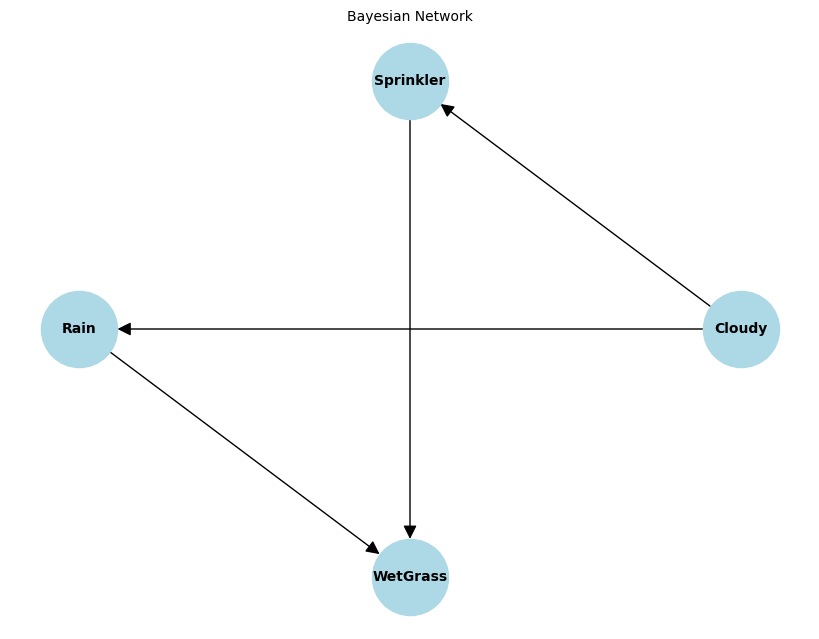

In [10]:
# Visualize the Bayesian Network
plt.figure(figsize=(8, 6))
pos = nx.circular_layout(model)
nx.draw(model, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Bayesian Network", size=10)
plt.show()

In [11]:
# Generate data samples for evaluation
bayesian_sampler = BayesianModelSampling(model)
samples_df = bayesian_sampler.forward_sample(size=10000)

# Map numerical states back to original string labels for better readability
state_map = {
    'Cloudy': {0: 'Not Cloudy', 1: 'Cloudy'},
    'Sprinkler': {0: 'Sprinkler Off', 1: 'Sprinkler On'},
    'Rain': {0: 'No Rain', 1: 'Rain'},
    'WetGrass': {0: 'Grass Dry', 1: 'Grass Wet'}
}

for col, mapping in state_map.items():
    if col in samples_df.columns:
        samples_df[col] = samples_df[col].map(mapping)

print("Generated Samples (first 5 rows):")
display(samples_df.head())


  0%|          | 0/4 [00:00<?, ?it/s]

Generated Samples (first 5 rows):


,Cloudy,Sprinkler,Rain,WetGrass
0,Not Cloudy,Sprinkler On,No Rain,Grass Dry
1,Not Cloudy,Sprinkler Off,No Rain,Grass Dry
2,Not Cloudy,Sprinkler On,Rain,Grass Wet
3,Cloudy,Sprinkler Off,No Rain,Grass Dry
4,Cloudy,Sprinkler Off,Rain,Grass Dry


In [12]:
#Model Evaluation with Log-Likelihood, AIC, BIC Calculation ---
#First, map the string labels in samples_df back to numerical for model processing
reverse_state_map = {
    'Cloudy': {'Not Cloudy': 0, 'Cloudy': 1},
    'Sprinkler': {'Sprinkler Off': 0, 'Sprinkler On': 1},
    'Rain': {'No Rain': 0, 'Rain': 1},
    'WetGrass': {'Grass Dry': 0, 'Grass Wet': 1}
}

samples_numeric_df = samples_df.copy()
for col, mapping in reverse_state_map.items():
    if col in samples_numeric_df.columns:
        samples_numeric_df[col] = samples_numeric_df[col].map(mapping)

log_likelihood = 0.0
for _, row in samples_numeric_df.iterrows():
    # Calculate joint probability P(C, S, R, WG) = P(C) * P(S|C) * P(R|C) * P(WG|S,R)
    p_c = cpd_cloudy.get_value(Cloudy=row['Cloudy'])
    p_s_given_c = cpd_sprinkler.get_value(Sprinkler=row['Sprinkler'], Cloudy=row['Cloudy'])
    p_r_given_c = cpd_rain.get_value(Rain=row['Rain'], Cloudy=row['Cloudy'])
    p_wg_given_s_r = cpd_wet_grass.get_value(WetGrass=row['WetGrass'], Sprinkler=row['Sprinkler'], Rain=row['Rain'])

    joint_prob = p_c * p_s_given_c * p_r_given_c * p_wg_given_s_r
    if joint_prob > 0: # Avoid log(0) for numerical stability
        log_likelihood += np.log(joint_prob)

# Calculate number of parameters manually as DiscreteBayesianNetwork does not have get_number_of_parameters()
num_params = 0
for cpd in model.get_cpds():
    # For a TabularCPD, parameters = (variable_card - 1) * product(evidence_cards)
    # The first element of cpd.cardinality is the variable's own cardinality, the rest are parents.
    evidence_cards_product = np.prod(cpd.cardinality[1:]) if len(cpd.cardinality) > 1 else 1
    num_params += (cpd.variable_card - 1) * evidence_cards_product

num_data_points = len(samples_numeric_df)

# AIC = 2k - 2ln(L)
aic = 2 * num_params - 2 * log_likelihood

# BIC = ln(n)k - 2ln(L)
bic = np.log(num_data_points) * num_params - 2 * log_likelihood

print(f"Log-Likelihood: {log_likelihood:.4f}")
print(f"AIC: {aic:.4f}")
print(f"BIC: {bic:.4f}")


Log-Likelihood: -19105.1998
AIC: 38228.3996
BIC: 38293.2927


In [13]:
#Other Metrics for Classification
true_labels = samples_numeric_df['WetGrass'].values
predicted_probabilities = []
predicted_labels = []

for _, row in samples_numeric_df.iterrows():
    evidence = {'Cloudy': row['Cloudy'], 'Sprinkler': row['Sprinkler'], 'Rain': row['Rain']}
    wetgrass_prob_dist = infer.query(variables=['WetGrass'], evidence=evidence, show_progress=False)
    prob_wet_grass_true = wetgrass_prob_dist.values[1] if 1 in wetgrass_prob_dist.state_names['WetGrass'] else 0.0

    predicted_probabilities.append(prob_wet_grass_true)
    predicted_labels.append(1 if prob_wet_grass_true >= 0.5 else 0) # Simple threshold for prediction

# Calculate classification metrics
print(f"Accuracy: {accuracy_score(true_labels, predicted_labels):.4f}")
print(f"Precision: {precision_score(true_labels, predicted_labels):.4f}")
print(f"F1-Score: {f1_score(true_labels, predicted_labels):.4f}")

conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("\nConfusion Matrix:")
print(conf_matrix)


Accuracy: 0.9359
Precision: 0.9083
F1-Score: 0.9519

Confusion Matrix:
[[3010  641]
 [   0 6349]]


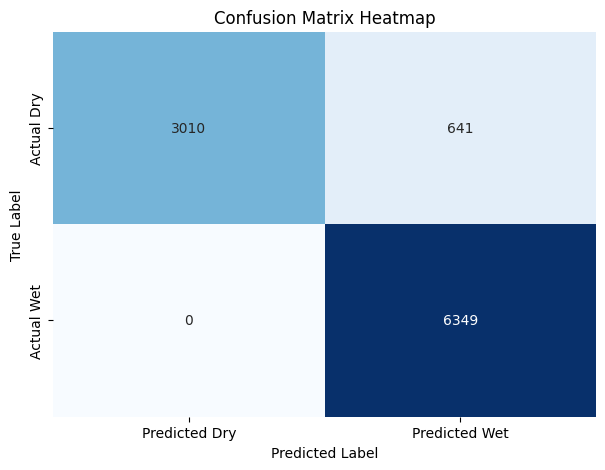

In [14]:
# Plotting the Confusion Matrix as a Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Dry', 'Predicted Wet'],
            yticklabels=['Actual Dry', 'Actual Wet']
            )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

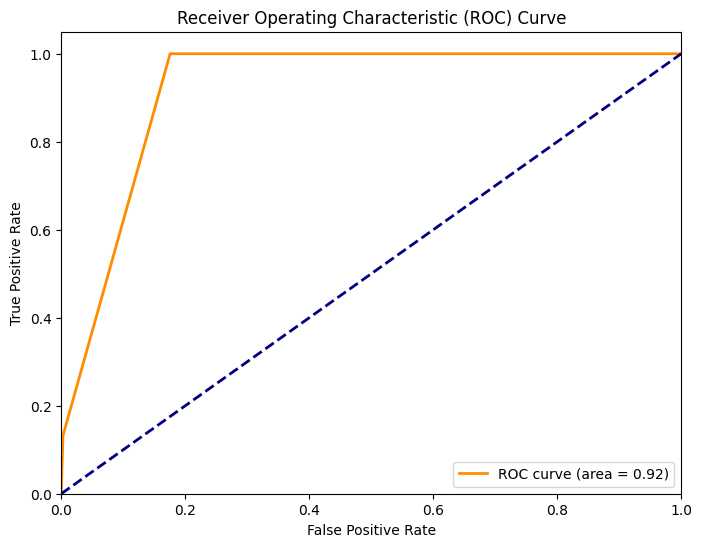

In [15]:
#ROC Curve for Model Evaluation
fpr, tpr, thresholds = roc_curve(true_labels, predicted_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()